In [1]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/motion_CNN
    filepath = "/content/drive/MyDrive/NUIN/mouse_scenes/20210916_252MEA_mouse_right_half_ventral/fixationmovie_data.mat" 
    !git pull
else: 
  filepath =  "mouse_scenes/20210916_252MEA_mouse_right_half_ventral/fixationmovie_data.mat"
    

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/NUIN/motion_CNN
Already up to date.


In [2]:
from utilities import CorrelationVelDataset, show_batch_frames, show_one_sample_summary, sample_animation, split_by_source_image, prerender_dataset_to_single_pt, TensorMovieDataset
from IPython.display import HTML, display
import torch.nn as nn
import torch.nn.functional as F
import torch
from torch.utils.data import Subset, DataLoader
import os 
import numpy as np
import matplotlib.pyplot as plt

# Set the resolution for figures displayed in the notebook
plt.rcParams['figure.dpi'] = 100


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   
print(f"Using device: {device}")
print(os.getcwd())

Using device: cuda
/content/drive/MyDrive/NUIN/motion_CNN


In [4]:
dataset = CorrelationVelDataset(
    file = filepath,
    crop_hw=(400,400),
    downsample_hw=(50,50),
    frames_per_segment=75,
    fps = 75,
    samples_per_image= 6, 
    vel_std = (350,350),
    vel_corr=-0.0
    )

print("dataset length:", len(dataset))

dataset length: 1950


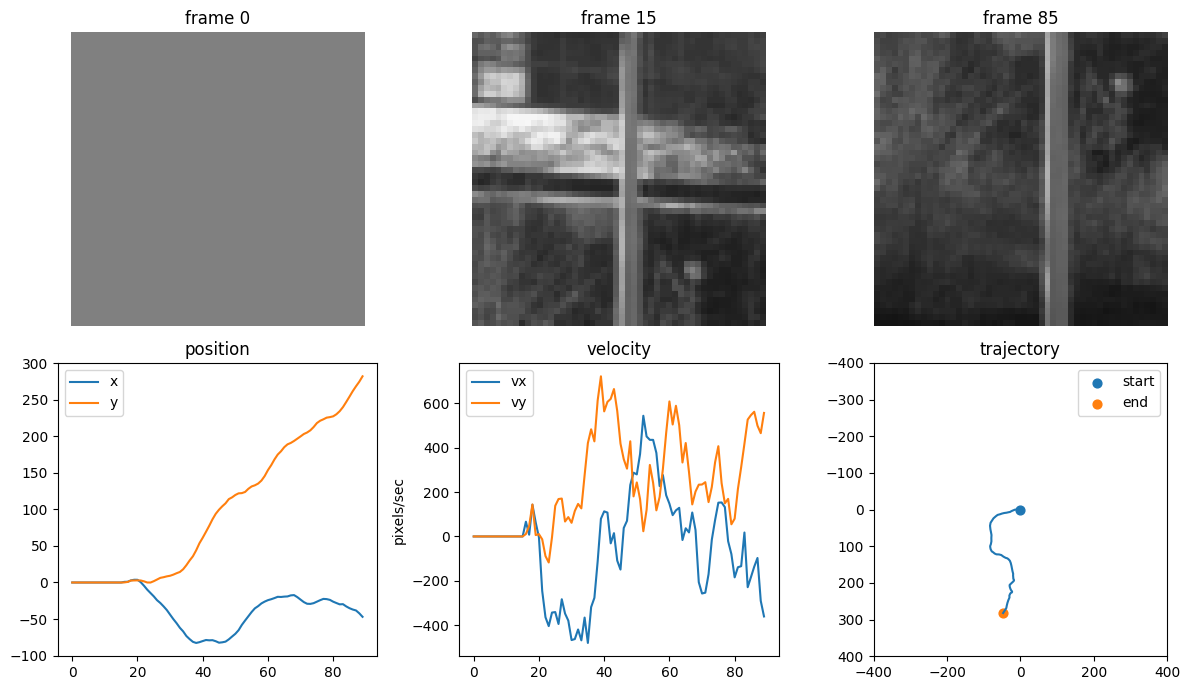

In [5]:
show_one_sample_summary(dataset, 0, frame_indices=[0,15,85])

In [ ]:

# anim = sample_animation(dataset, 0, viz_fps=20, save_path=None)
# display(HTML(anim.to_jshtml()))

# Split/Val sets

In [ ]:

train_dataset, val_dataset, train_keys, val_keys = split_by_source_image(
    dataset,
    train_frac=0.8,
    val_frac=0.2,
    seed=0,
)
print("Total samples:", len(dataset))
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

print("Train images:", len(train_keys))
print("Val images:", len(val_keys))

print("Overlap:", len(train_keys & val_keys))

Total samples: 1950
Train samples: 1560
Val samples: 390
Train images: 260
Val images: 65
Overlap: 0


In [8]:
cache_name_train = (
    f"corrvel_train_"
    f"hw{dataset.downsample_hw[0]}x{dataset.downsample_hw[1]}_"
    f"T{dataset.frames_per_segment}_"
    f"gray{dataset.gray_frames}_"
    f"std{dataset.vel_std}_"
    f"corr{dataset.vel_corr}_"
    f"seed{dataset.random_seed}.pt"
)

cache_name_val = (
    f"corrvel_val_"
    f"hw{dataset.downsample_hw[0]}x{dataset.downsample_hw[1]}_"
    f"T{dataset.frames_per_segment}_"
    f"gray{dataset.gray_frames}_"
    f"std{dataset.vel_std}_"
    f"corr{dataset.vel_corr}_"
    f"seed{dataset.random_seed}.pt"
)

train_cache = prerender_dataset_to_single_pt(
    dataset,
    train_dataset.indices,
    f"cache/{cache_name_train}",
    movie_dtype=torch.float16,
    overwrite=False,
)

val_cache = prerender_dataset_to_single_pt(
    dataset,
    val_dataset.indices,
    f"cache/{cache_name_val}",
    movie_dtype=torch.float16,
    overwrite=False,
)

Cache already exists, skipping render: cache/corrvel_train_hw50x50_T75_gray15_std(350, 350)_corr-0.0_seed0.pt
Cache already exists, skipping render: cache/corrvel_val_hw50x50_T75_gray15_std(350, 350)_corr-0.0_seed0.pt


In [9]:
cached_train = TensorMovieDataset(f"cache/{cache_name_train}", movie_dtype=torch.float32)
cached_val = TensorMovieDataset(f"cache/{cache_name_val}", movie_dtype=torch.float32)

train_loader = DataLoader(
    cached_train,
    batch_size=16,
    shuffle=True,
    num_workers=0,   # try 0 first; increase later
    pin_memory=True,
)

val_loader = DataLoader(
    cached_val,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

## Build minimal CNN with separable first layer

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F


def gaussian_2d_kernel(kernel_h, kernel_w, std, device=None, dtype=None):
    """
    Create a centered 2D Gaussian kernel normalized to max=1.
    Shape: (kernel_h, kernel_w)
    """
    y = torch.arange(kernel_h, device=device, dtype=dtype) - (kernel_h - 1) / 2
    x = torch.arange(kernel_w, device=device, dtype=dtype) - (kernel_w - 1) / 2

    yy, xx = torch.meshgrid(y, x, indexing="ij")

    g = torch.exp(-(xx**2 + yy**2) / (2 * std**2))
    g = g / g.max()

    return g

class SeparableSTLayer(nn.Module):
    """
    Rank-1 separable spatiotemporal layer.

    movie: (B, T, 1, H, W)
    output: (B, hidden, T, H, W)

    Computation:
        spatial Conv2d per frame
        temporal Conv1d per channel, shared over space
    """

    def __init__(
        self,
        in_channels=1,
        n_sep_filt=8,
        spatial_kernel=5,
        temporal_kernel=5,
        spatial_padding=None,
        temporal_causal=True,
        gauss_prior=0.0,
    ):
        super().__init__()

        if spatial_padding is None:
            spatial_padding = spatial_kernel // 2

        self.hidden = n_sep_filt
        self.temporal_kernel = temporal_kernel
        self.temporal_causal = temporal_causal
        self.gauss_prior = gauss_prior

        self.spatial_conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels=n_sep_filt,
            kernel_size=spatial_kernel,
            padding=spatial_padding,
            bias=True,
        )

        # groups=hidden means one temporal filter per spatial channel
        self.temporal_conv = nn.Conv1d(
            in_channels=n_sep_filt,
            out_channels=n_sep_filt,
            kernel_size=temporal_kernel,
            groups=n_sep_filt,
            bias=True,
        )

        if self.gauss_prior > 0:
            self.initialize_spatial_gaussian_prior(std=self.gauss_prior)

    def initialize_spatial_gaussian_prior(self, std):
        """
        Initialize each spatial Conv2d filter as a positive Gaussian blob.

        This mimics the Gaussian initialization used in the BNCNN code:
        it is an initialization, not a hard DoG constraint.
        """
        weight = self.spatial_conv.weight.data
        out_ch, in_ch, kh, kw = weight.shape

        g = gaussian_2d_kernel(
            kh,
            kw,
            std=std,
            device=weight.device,
            dtype=weight.dtype,
        )

        # Similar scaling idea to the uploaded BNCNN:
        # prior = prior / max(prior) / sqrt(out_ch + in_ch)
        scale = torch.sqrt(torch.tensor(out_ch + in_ch, device=weight.device, dtype=weight.dtype))
        g = g / scale

        for o in range(out_ch):
            for i in range(in_ch):
                weight[o, i] = g

        if self.spatial_conv.bias is not None:
            nn.init.zeros_(self.spatial_conv.bias)

    def forward(self, movie):
        """
        movie: (B, T, 1, H, W)
        returns: (B, hidden, T, H, W)
        """
        B, T, C, H, W = movie.shape

        # Spatial filtering per frame
        x = movie.reshape(B * T, C, H, W)
        x = self.spatial_conv(x)

        _, Fch, H1, W1 = x.shape
        x = x.reshape(B, T, Fch, H1, W1)

        # Temporal filtering per channel at each spatial location
        x = x.permute(0, 3, 4, 2, 1)
        x = x.reshape(B * H1 * W1, Fch, T)

        if self.temporal_causal:
            x = F.pad(x, (self.temporal_kernel - 1, 0))
        else:
            left = self.temporal_kernel // 2
            right = self.temporal_kernel - 1 - left
            x = F.pad(x, (left, right))

        x = self.temporal_conv(x)

        x = x.reshape(B, H1, W1, Fch, T)
        x = x.permute(0, 3, 4, 1, 2)

        return x
    

class FramewiseConv2D(nn.Module):
    """
    Apply Conv2d independently to each time frame.

    Input:  (B, C, T, H, W)
    Output: (B, hidden, T, H, W)
    """
    def __init__(self, in_channels, hidden, kernel_size=11):
        super().__init__()

        self.net = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Conv2d(
                in_channels,
                hidden,
                kernel_size=kernel_size,
                padding=kernel_size // 2,
            ),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        B, C, T, H, W = x.shape

        x = x.permute(0, 2, 1, 3, 4)      # (B, T, C, H, W)
        x = x.reshape(B * T, C, H, W)     # (B*T, C, H, W)

        y = self.net(x)                   # (B*T, hidden, H, W)

        _, hidden, H, W = y.shape
        y = y.reshape(B, T, hidden, H, W)
        y = y.permute(0, 2, 1, 3, 4)      # (B, hidden, T, H, W)

        return y

In [11]:
class MinimalCNN(nn.Module):
    def __init__(
        self,
        separable_filts=8,
        hidden=12,
        num_neurons=8,
        out_dim=2,
        initial_rate=1.0,
        spatial_kernel_1=9,
        spatial_kernel_2=11,
        temporal_kernel_1=45,
        temporal_causal=True,
        decoder_init_std=0.05,
        gauss_prior=2.0,
    ):
        super().__init__()

        self.st_layer1 = SeparableSTLayer(
            in_channels=1,
            n_sep_filt=separable_filts,
            spatial_kernel=spatial_kernel_1,
            temporal_kernel=temporal_kernel_1,
            temporal_causal=temporal_causal,
            gauss_prior=gauss_prior,
        )

        self.encoder_rest = FramewiseConv2D(
            in_channels=separable_filts,
            hidden=hidden,
            kernel_size=spatial_kernel_2,
        )

        self.rate_readout = nn.Linear(hidden, num_neurons)
        self.decoder = nn.Linear(num_neurons, out_dim)

        bias = torch.log(torch.exp(torch.tensor(float(initial_rate))) - 1.0)
        nn.init.constant_(self.rate_readout.bias, bias)

        nn.init.normal_(self.decoder.weight, mean=0.0, std=decoder_init_std)
        nn.init.zeros_(self.decoder.bias)

    def forward(self, movie, return_rates=False, return_features=False):
        x = self.st_layer1(movie)          # (B, separable_filts, T, H, W)
        z = self.encoder_rest(x)           # (B, hidden, T, H, W)

        z_pool = z.mean(dim=(-1, -2))      # (B, hidden, T)
        z_pool = z_pool.permute(0, 2, 1)   # (B, T, hidden)

        drive = self.rate_readout(z_pool)
        rates = F.softplus(drive) + 1e-4

        pred = self.decoder(rates)

        if return_features:
            extras = {
                "st_features": x,
                "encoder_features": z,
                "rates": rates,
            }
            return pred, extras

        if return_rates:
            return pred, rates

        return pred

In [12]:
from utilities import compute_velocity_stats, direct_velocity_loss
gray_frames = train_dataset.dataset.gray_frames

vel_mean, vel_std = compute_velocity_stats(
    train_dataset.dataset,
    indices=train_dataset.indices,
    device=device,
)

print("vel_mean:", vel_mean)
print("vel_std:", vel_std)

vel_mean: tensor([-0.9307, -0.5621], device='cuda:0')
vel_std: tensor([322.0383, 322.3994], device='cuda:0')


In [14]:
batch = next(iter(train_loader))

movie = batch["movie"].to(device)
target = batch["scene_vel"].to(device)

# tiny = TinyMotionCNN(hidden=16).to(device)
# tiny = TinyRateMotionCNN(hidden=16).to(device)
model = MinimalCNN(
    separable_filts=8,
    hidden=12,
    num_neurons=8,
    spatial_kernel_1=9,
    spatial_kernel_2=11,
    temporal_kernel_1=45,
    gauss_prior=2.0,
).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0)

for step in range(300):
    pred = model(movie)

    loss = direct_velocity_loss(
        pred_vel_z=pred,
        target_vel=target,
        vel_mean=vel_mean,
        vel_std=vel_std,
        gray_frames=gray_frames,
    )

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if step % 25 == 0:
        print(step, loss.item())

0 1.0537713766098022
25 0.9982076287269592
50 0.9608667492866516
75 0.9119536280632019
100 0.8836315870285034
125 0.8632155656814575
150 0.8441544771194458
175 0.8316230177879333
200 0.8156298995018005
225 0.7992875576019287
250 0.7868773341178894
275 0.7831246852874756


## Train tiny CNN in whole dataset

In [15]:
print("train batches per epoch:", len(train_loader))
print("val batches per epoch:", len(val_loader))
print("train samples:", len(train_loader.dataset))
print("val samples:", len(val_loader.dataset))

train batches per epoch: 98
val batches per epoch: 25
train samples: 1560
val samples: 390


In [16]:
from tqdm.auto import tqdm
import matplotlib.pyplot as plt


model = MinimalCNN(
    separable_filts=8,
    hidden=12,
    num_neurons=8,
    spatial_kernel_1=9,
    spatial_kernel_2=11,
    temporal_kernel_1=45,
    gauss_prior=2.0,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

history = {
    "train_loss": [],
    "val_loss": [],
}


def run_epoch_direct(
    model,
    loader,
    optimizer=None,
    vel_mean=None,
    vel_std=None,
    gray_frames=15,
    device="cpu",
    desc="",
):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_n = 0

    pbar = tqdm(loader, desc=desc, leave=False)

    for batch in pbar:
        movie = batch["movie"].to(device)
        target = batch["scene_vel"].to(device)

        pred = model(movie)

        loss = direct_velocity_loss(
            pred_vel_z=pred,
            target_vel=target,
            vel_mean=vel_mean,
            vel_std=vel_std,
            gray_frames=gray_frames,
        )

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        B = movie.shape[0]
        total_loss += loss.item() * B
        total_n += B

        pbar.set_postfix({"vel": total_loss / total_n})

    return total_loss / total_n


num_epochs = 30

for epoch in range(1, num_epochs + 1):
    train_loss = run_epoch_direct(
        model,
        train_loader,
        optimizer=optimizer,
        vel_mean=vel_mean,
        vel_std=vel_std,
        gray_frames=gray_frames,
        device=device,
        desc=f"Tiny instant epoch {epoch:03d} train",
    )

    with torch.no_grad():
        val_loss = run_epoch_direct(
            model,
            val_loader,
            optimizer=None,
            vel_mean=vel_mean,
            vel_std=vel_std,
            gray_frames=gray_frames,
            device=device,
            desc=f"Tiny instant epoch {epoch:03d} val",
        )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch {epoch:03d} | train {train_loss:.4f} | val {val_loss:.4f}")

Tiny instant epoch 001 train:   0%|          | 0/98 [00:00<?, ?it/s]

Tiny instant epoch 001 val:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 001 | train 1.0011 | val 0.9671


Tiny instant epoch 002 train:   0%|          | 0/98 [00:00<?, ?it/s]

Tiny instant epoch 002 val:   0%|          | 0/25 [00:00<?, ?it/s]

...

Tiny instant epoch 029 val:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 029 | train 0.1601 | val 0.1527


Tiny instant epoch 030 train:   0%|          | 0/98 [00:00<?, ?it/s]

Tiny instant epoch 030 val:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 030 | train 0.1506 | val 0.1551


## Evaluate performance

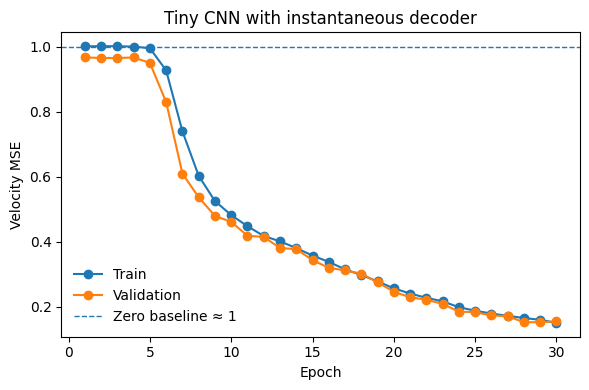

In [17]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], marker="o", label="Train")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation")
plt.axhline(1.0, linestyle="--", linewidth=1, label="Zero baseline ≈ 1")
plt.xlabel("Epoch")
plt.ylabel("Velocity MSE")
plt.title("Tiny CNN with instantaneous decoder")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [19]:
import numpy as np
import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def compute_val_r2_per_movie(
    model,
    val_loader,
    vel_mean,
    vel_std,
    gray_frames,
    device,
):
    model.eval()

    r2_per_seq = []
    pred_all = []
    target_all = []

    for batch in val_loader:
        movie = batch["movie"].to(device)
        target = batch["scene_vel"].to(device)  # raw px/s, (B, T, 2)

        pred_z = model(movie)                   # normalized, (B, T, 2)
        pred = pred_z * vel_std + vel_mean      # back to px/s

        pred = pred[:, gray_frames:, :]
        target = target[:, gray_frames:, :]

        # Per movie R² over both vx and vy together
        ss_res = ((target - pred) ** 2).sum(dim=(1, 2))
        target_mean = target.mean(dim=(1, 2), keepdim=True)
        ss_tot = ((target - target_mean) ** 2).sum(dim=(1, 2))

        r2 = 1.0 - ss_res / (ss_tot + 1e-8)

        r2_per_seq.extend(r2.detach().cpu().numpy())
        pred_all.append(pred.detach().cpu())
        target_all.append(target.detach().cpu())

    r2_per_seq = np.asarray(r2_per_seq)
    pred_all = torch.cat(pred_all, dim=0)        # (Nval, T-gray, 2)
    target_all = torch.cat(target_all, dim=0)

    return r2_per_seq, pred_all, target_all

r2_per_seq, pred_val, target_val = compute_val_r2_per_movie(
    model=model,
    val_loader=val_loader,
    vel_mean=vel_mean,
    vel_std=vel_std,
    gray_frames=gray_frames,
    device=device,
)

mean_r2 = np.mean(r2_per_seq)
sem_r2 = np.std(r2_per_seq, ddof=1) / np.sqrt(len(r2_per_seq))

print("Mean R²:", mean_r2)
print("SEM R²:", sem_r2)
print("N validation movies:", len(r2_per_seq))
print("Min/Max R²:", r2_per_seq.min(), r2_per_seq.max())

Mean R²: 0.7834301
SEM R²: 0.00659045375961547
N validation movies: 390
Min/Max R²: -0.31728804 0.9340202


/tmp/ipykernel_52113/2314121497.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


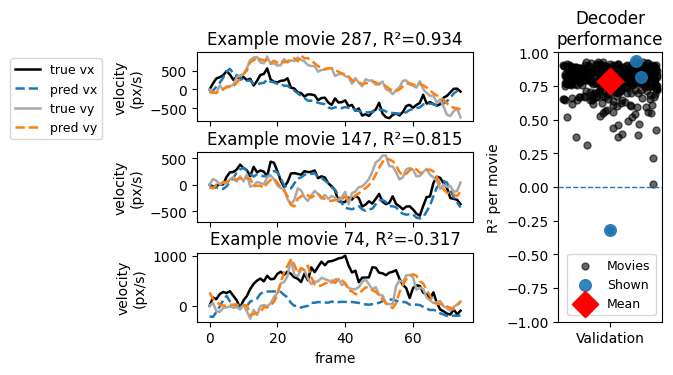

In [20]:
from matplotlib.gridspec import GridSpec


def plot_validation_summary_two_columns(
    r2_per_seq,
    pred_val,
    target_val,
    n_examples=3,
    example_mode="best",  # "best", "worst", or "mixed"
    figsize=(11, 7),
):
    # Convert tensors to numpy if needed
    if hasattr(pred_val, "detach"):
        pred_val_np = pred_val.detach().cpu().numpy()
    else:
        pred_val_np = np.asarray(pred_val)

    if hasattr(target_val, "detach"):
        target_val_np = target_val.detach().cpu().numpy()
    else:
        target_val_np = np.asarray(target_val)

    r2_per_seq = np.asarray(r2_per_seq)

    # Choose example indices
    order = np.argsort(r2_per_seq)

    if example_mode == "best":
        example_idxs = order[-n_examples:][::-1]
    elif example_mode == "worst":
        example_idxs = order[:n_examples]
    elif example_mode == "mixed":
        example_idxs = np.array([
            order[-1],
            order[len(order) // 2],
            order[0],
        ])
        example_idxs = example_idxs[:n_examples]
    else:
        raise ValueError("example_mode must be 'best', 'worst', or 'mixed'.")

    mean_r2 = np.mean(r2_per_seq)
    sem_r2 = np.std(r2_per_seq, ddof=1) / np.sqrt(len(r2_per_seq))

    # Figure layout
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(
        nrows=len(example_idxs),
        ncols=2,
        width_ratios=[3.2, 1.2],
        wspace=0.45,
        hspace=0.45,
        figure=fig,
    )

    # -----------------------------
    # Left column: example traces
    # -----------------------------
    for row, idx in enumerate(example_idxs):
        ax = fig.add_subplot(gs[row, 0])

        pred = pred_val_np[idx]
        target = target_val_np[idx]

        t = np.arange(target.shape[0])

        ax.plot(t, target[:, 0], label="true vx", linewidth=1.8, c='k')
        ax.plot(t, pred[:, 0], label="pred vx", linewidth=1.8, linestyle="--")

        ax.plot(t, target[:, 1], label="true vy", linewidth=1.8, c='darkgray')
        ax.plot(t, pred[:, 1], label="pred vy", linewidth=1.8, linestyle="--")

        ax.set_title(f"Example movie {idx}, R²={r2_per_seq[idx]:.3f}")
        ax.set_ylabel("velocity\n(px/s)")

        if row == len(example_idxs) - 1:
            ax.set_xlabel("frame")
        else:
            ax.set_xticklabels([])

        if row == 0:
            ax.legend(ncol=1, fontsize=9, loc="upper left",
                      bbox_to_anchor=(-.7, 1.0),)

    # -----------------------------
    # Right column: R² scatter plot
    # -----------------------------
    ax_r2 = fig.add_subplot(gs[:, 1])

    x0 = 0
    rng = np.random.default_rng(0)
    x_jitter = x0 + rng.uniform(-0.15, 0.15, size=len(r2_per_seq))

    ax_r2.scatter(
        x_jitter,
        r2_per_seq,
        alpha=0.6,
        s=25,
        c="k",
        label="Movies",
    )

    # Highlight selected examples
    ax_r2.scatter(
        x_jitter[example_idxs],
        r2_per_seq[example_idxs],
        alpha=0.9,
        s=70,
        c="tab:blue",
        label="Shown",
    )

    # Mean marker + SEM
    ax_r2.scatter(
        x0,
        mean_r2,
        s=180,
        marker="D",
        c="red",
        label="Mean",
        zorder=5,
    )

    ax_r2.errorbar(
        x0,
        mean_r2,
        yerr=sem_r2,
        fmt="none",
        ecolor="red",
        capsize=5,
        linewidth=2,
        zorder=4,
    )

    ax_r2.axhline(0, linestyle="--", linewidth=1)
    ax_r2.set_xticks([x0])
    ax_r2.set_xticklabels(["Validation"])
    ax_r2.set_ylim(-1, 1)
    ax_r2.set_ylabel("R² per movie")
    ax_r2.set_title("Decoder\nperformance")
    ax_r2.legend(fontsize=9, loc="lower right")

    # fig.suptitle("Validation performance summary", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

    return fig

fig = plot_validation_summary_two_columns(
    r2_per_seq=r2_per_seq,
    pred_val=pred_val,
    target_val=target_val,
    n_examples=3,
    example_mode="mixed",
    figsize=(6, 3.5),
)

In [21]:
@torch.no_grad()
def rate_velocity_correlations(model, loader, gray_frames, device):
    model.eval()

    all_rates = []
    all_vel = []

    for batch in loader:
        movie = batch["movie"].to(device)
        vel = batch["scene_vel"].to(device)

        pred, rates = model(movie, return_rates=True)

        rates = rates[:, gray_frames:, :]  # (B,T,N)
        vel = vel[:, gray_frames:, :]      # (B,T,2)

        all_rates.append(rates.reshape(-1, rates.shape[-1]).cpu())
        all_vel.append(vel.reshape(-1, 2).cpu())

    R = torch.cat(all_rates, dim=0)  # (samples, N)
    V = torch.cat(all_vel, dim=0)    # (samples, 2)

    R = R - R.mean(dim=0, keepdim=True)
    V = V - V.mean(dim=0, keepdim=True)

    corr = (R.T @ V) / (
        torch.sqrt((R**2).sum(dim=0, keepdim=True)).T
        * torch.sqrt((V**2).sum(dim=0, keepdim=True))
        + 1e-8
    )

    return corr.numpy()

corr = rate_velocity_correlations(
    model,
    val_loader,
    gray_frames=gray_frames,
    device=device,
)
print("[neuron, (vx, vy)] correlations:")
print(corr)  # shape (num_neurons, 2)

[neuron, (vx, vy)] correlations:
[[ 0.08145852  0.71320564]
 [-0.7002066   0.42844883]
 [ 0.74247664 -0.32143754]
 [ 0.54752594  0.30868942]
 [-0.6364262   0.09738818]
 [ 0.53395957 -0.4347598 ]
 [-0.21006528 -0.772849  ]
 [ 0.28909075  0.70861363]]


In [22]:
corr = rate_velocity_correlations(model, val_loader, gray_frames, device)

pref_angle = np.arctan2(corr[:, 1], corr[:, 0])
pref_strength = np.linalg.norm(corr, axis=1)

for i, (ang, strength) in enumerate(zip(pref_angle, pref_strength)):
    print(
        f"unit {i:02d}: angle={np.degrees(ang):7.1f} deg, "
        f"strength={strength:.3f}, corr_vx={corr[i,0]:.3f}, corr_vy={corr[i,1]:.3f}"
    )

unit 00: angle=   83.5 deg, strength=0.718, corr_vx=0.081, corr_vy=0.713
unit 01: angle=  148.5 deg, strength=0.821, corr_vx=-0.700, corr_vy=0.428
unit 02: angle=  -23.4 deg, strength=0.809, corr_vx=0.742, corr_vy=-0.321
unit 03: angle=   29.4 deg, strength=0.629, corr_vx=0.548, corr_vy=0.309
unit 04: angle=  171.3 deg, strength=0.644, corr_vx=-0.636, corr_vy=0.097
unit 05: angle=  -39.2 deg, strength=0.689, corr_vx=0.534, corr_vy=-0.435
unit 06: angle= -105.2 deg, strength=0.801, corr_vx=-0.210, corr_vy=-0.773
unit 07: angle=   67.8 deg, strength=0.765, corr_vx=0.289, corr_vy=0.709


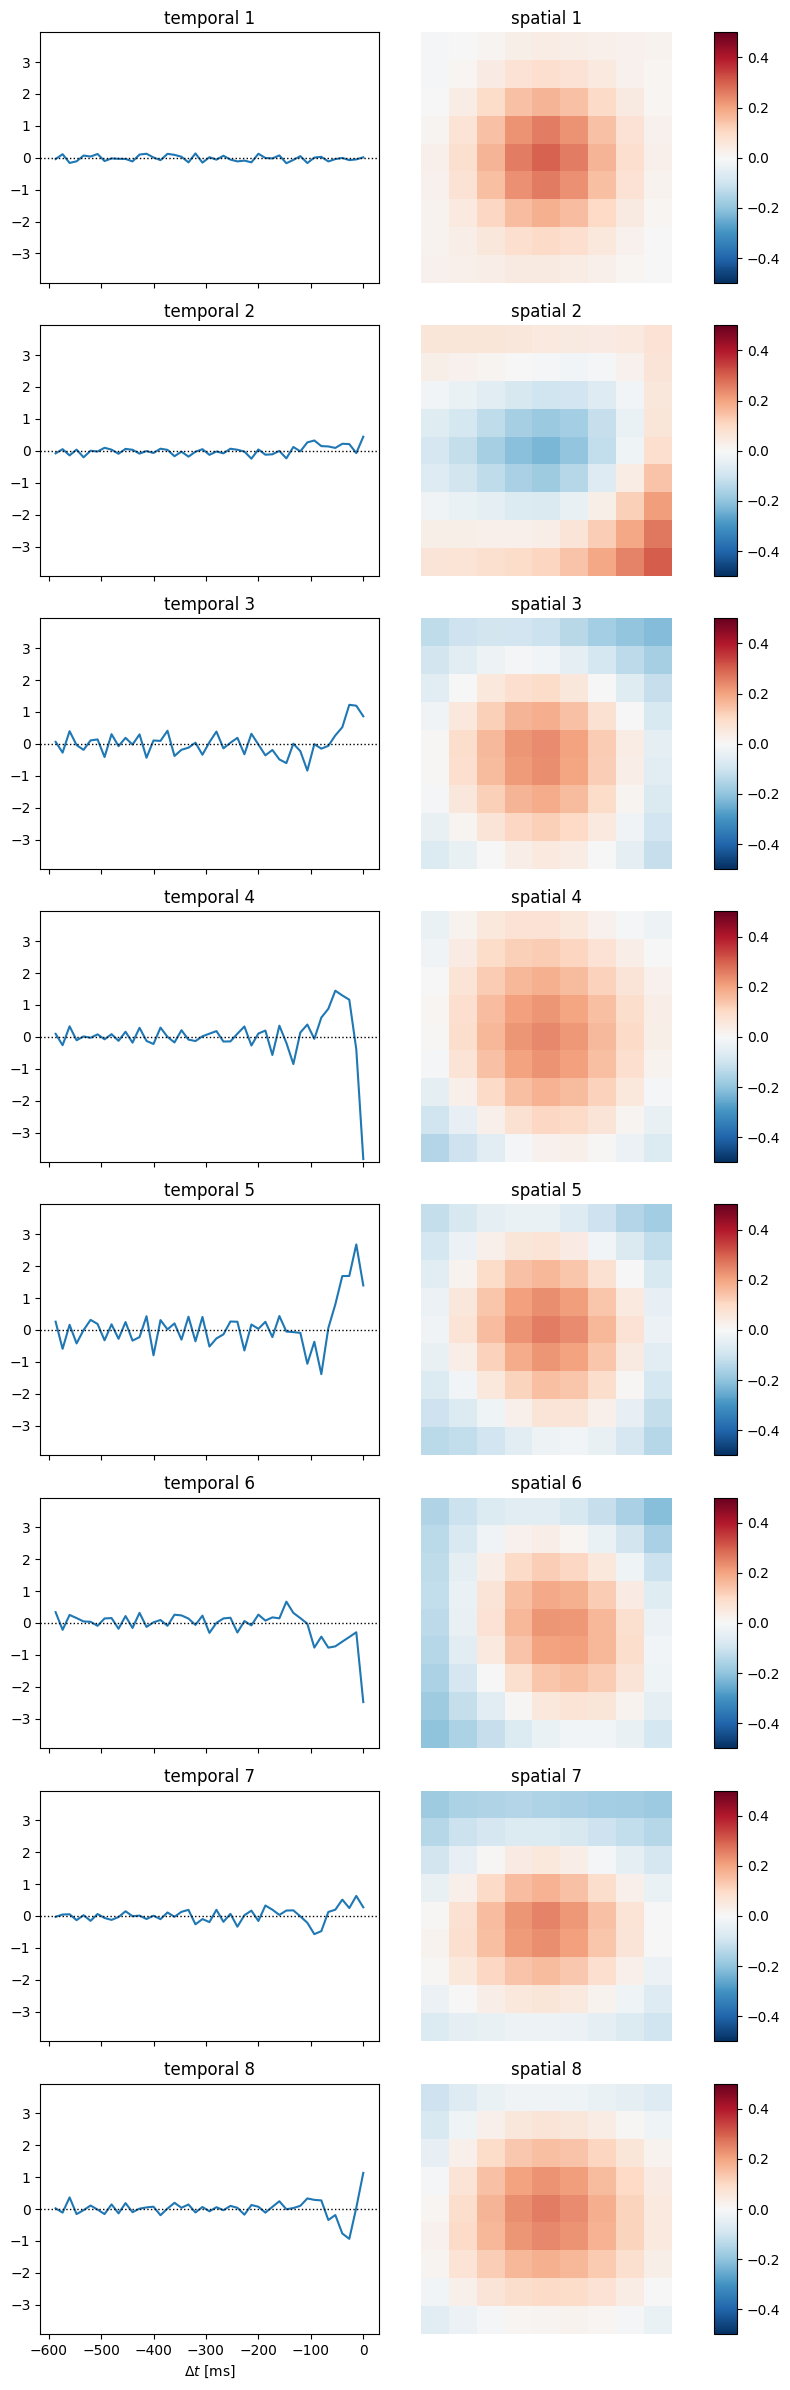

In [26]:
import torch
import matplotlib.pyplot as plt


def plot_separable_first_layer(model, dt_ms=None, flip_sign=True):
    """
    Visualize the first separable spatiotemporal layer.

    For TinyRateMotionCNNSeparableFirst:
        model.st_layer1.spatial_conv.weight:  (hidden, 1, Kh, Kw)
        model.st_layer1.temporal_conv.weight: (hidden, 1, Kt)

    Parameters
    ----------
    model : nn.Module
        TinyRateMotionCNNSeparableFirst model.
    dt_ms : float or None
        Frame duration in ms. 
        Example: 1000 / 75 for 75 Hz movies.
        If None, plots temporal filter in frame units.
    flip_sign : bool
        If True, flips spatial and temporal filters so the largest spatial peak is positive.
        This is valid because separable filters have sign ambiguity:
            spatial * temporal = (-spatial) * (-temporal)
    """

    layer = model.st_layer1

    spatial_weights = layer.spatial_conv.weight.detach().cpu()[:, 0, :, :]   # (hidden, Kh, Kw)
    temporal_weights = layer.temporal_conv.weight.detach().cpu()[:, 0, :]    # (hidden, Kt)

    hidden = spatial_weights.shape[0]
    Kt = temporal_weights.shape[1]

    # Copy so we do not modify model weights
    spatial_weights = spatial_weights.clone()
    temporal_weights = temporal_weights.clone()

    # Normalize separable components for visualization
    for n in range(hidden):
        if flip_sign:
            # If the strongest spatial value is negative, flip both spatial and temporal parts
            max_abs_idx = torch.argmax(torch.abs(spatial_weights[n]))
            strongest_value = spatial_weights[n].flatten()[max_abs_idx]

            if strongest_value < 0:
                spatial_weights[n] *= -1
                temporal_weights[n] *= -1

        scale = torch.linalg.norm(spatial_weights[n])

        if scale > 0:
            spatial_weights[n] /= scale
            temporal_weights[n] *= scale

    # vlim = torch.abs(spatial_weights).max().item()
    vlim = 0.5
    ylim = torch.abs(temporal_weights).max().item() + .1

    fig, axs = plt.subplots(
        hidden,
        3,
        figsize=(8, 3.0 * hidden),
        gridspec_kw=dict(width_ratios=[1.2, 1.4, 0.08]),
        squeeze=False,
    )

    if dt_ms is None:
        t_axis = torch.arange(Kt)
        xlabel = "temporal lag [frames]"
    else:
        if layer.temporal_causal:
            # causal filter: oldest to current frame
            t_axis = torch.arange(-Kt + 1, 1) * dt_ms
        else:
            # centered filter
            left = Kt // 2
            right = Kt - 1 - left
            t_axis = torch.arange(-left, right + 1) * dt_ms

        xlabel = r"$\Delta t$ [ms]"

    for n in range(hidden):
        # Temporal filter
        axs[n, 0].plot(t_axis, temporal_weights[n])
        axs[n, 0].axhline(0, linestyle=":", color="k", linewidth=1)
        axs[n, 0].set_ylim(-ylim, ylim)
        axs[n, 0].set_title(f"temporal {n + 1}")

        if n < hidden - 1:
            axs[n, 0].set_xticklabels([])
        else:
            axs[n, 0].set_xlabel(xlabel)

        # Spatial filter
        im = axs[n, 1].imshow(
            spatial_weights[n],
            vmin=-vlim,
            vmax=vlim,
            cmap="RdBu_r",
        )
        axs[n, 1].set_axis_off()
        axs[n, 1].set_title(f"spatial {n + 1}")

        plt.colorbar(im, cax=axs[n, 2])

    plt.tight_layout()
    return fig, axs

plot_separable_first_layer(
    model,
    dt_ms=1000 / 75,   # or 1000 / 60 if your movies are 60 Hz
)
plt.show()

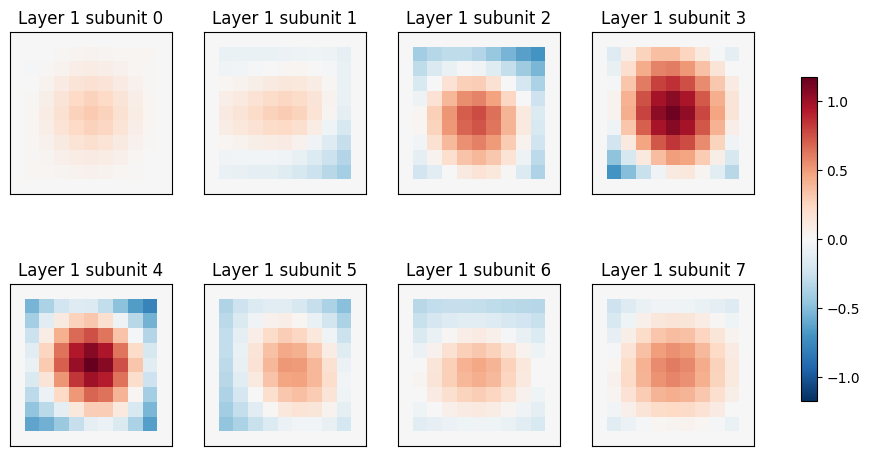

In [24]:

import numpy as np
import torch
import matplotlib.pyplot as plt


def embed_kernel_in_canvas(kernel, canvas_hw=(50, 50), center=None):
    """
    Put a small spatial kernel into a larger zero canvas.

    Parameters
    ----------
    kernel : array-like, shape (kH, kW)
    canvas_hw : tuple
        Full image size, e.g. (50, 50).
    center : tuple or None
        Center position (cy, cx). If None, use canvas center.

    Returns
    -------
    canvas : ndarray, shape canvas_hw
    """
    kernel = np.asarray(kernel)
    H, W = canvas_hw
    kH, kW = kernel.shape

    if center is None:
        cy, cx = H // 2, W // 2
    else:
        cy, cx = center

    y0 = cy - kH // 2
    x0 = cx - kW // 2
    y1 = y0 + kH
    x1 = x0 + kW

    canvas = np.zeros((H, W), dtype=np.float32)
    canvas[y0:y1, x0:x1] = kernel

    return canvas

def plot_first_layer_kernels_in_context(
    model,
    canvas_hw=(50, 50),
    n_cols=4,
    cmap="RdBu_r",
):
    W = model.st_layer1.spatial_conv.weight.detach().cpu().numpy()
    # W shape: (hidden, 1, kH, kW)

    hidden = W.shape[0]
    n_rows = int(np.ceil(hidden / n_cols))

    # Use shared color limits across all kernels
    vmax = np.abs(W).max()
    vmin = -vmax

    fig, axs = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3 * n_cols, 3 * n_rows),
        squeeze=False,
    )

    for i in range(hidden):
        ax = axs.flat[i]

        kernel = W[i, 0]
        canvas = embed_kernel_in_canvas(kernel, canvas_hw=canvas_hw)

        im = ax.imshow(canvas, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"Layer 1 subunit {i}")
        ax.set_xticks([])
        ax.set_yticks([])

        # Draw rectangle around actual kernel support
        H, Wcanvas = canvas_hw
        kH, kW = kernel.shape
        cy, cx = H // 2, Wcanvas // 2
        y0 = cy - kH // 2
        x0 = cx - kW // 2

        # rect = plt.Rectangle(
        #     (x0 - 0.5, y0 - 0.5),
        #     kW,
        #     kH,
        #     fill=False,
        #     linewidth=1.5,
        #     color="k",
        # )
        # ax.add_patch(rect)

    for j in range(hidden, n_rows * n_cols):
        axs.flat[j].axis("off")

    fig.colorbar(im, ax=axs.ravel().tolist(), shrink=0.7)
    plt.show()

plot_first_layer_kernels_in_context(
    model,
    canvas_hw=(11, 11),
    n_cols=4,
)